In [1]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import numpy as np
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# set up some print options
#np.set_printoptions(precision = 3, suppress = True)
torch.set_printoptions(precision=2,linewidth=160)
#begin loggin
cur_dir = 'synthetic' 
fig_dir = 'fig' 

os.makedirs(cur_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# Set up common problem parameters
lr = 0.02
clip_r = lr
n = 10        # dimension
n_head = 1  # 1-headed attention
batch_size = 1000  # 1000 minibatch size
var = 0.1  # initializations scale of transformer parameter
max_iters = 10100  # Number of Iterations to run
stride = 100


device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
#torch.cuda.set_device(0)

In [2]:
def gen_fc_unit_incidence(n):
    d = int(n * (n-1)/2)
    B = torch.zeros(n, d).cuda()
    edge_id = 0
    for i in range(n):
        for j in range(n):
            if j <=i:
                continue
            else:
                B[i,edge_id] = 1
                B[j,edge_id] = -1
                edge_id += 1
    return B.to(device)

def gen_csl_unit_incidence(n):
    d = 2*n
    B = torch.zeros(4, n, d).to(device)
    skip_values = [2,4,6,8]
    # loop over skip values
    for sk_i in range(len(skip_values)):
        list_src = []
        list_dst = []
        skip_value = skip_values[sk_i]
        for i in range(n):
            # cycle
            list_src.append(i)
            list_dst.append((i+1)%n)
            # skip connection
            list_src.append(i)
            list_dst.append((i+skip_value)%n)
        for (ind_e, (i,j)) in enumerate(zip(list_src, list_dst)):
            B[sk_i, i, ind_e] = 1
            B[sk_i, j, ind_e] = -1
    return B
def get_laplacian(B):
    #i is batch index
    return torch.einsum('ijk,ilk->ijl', B, B)
'''
print((get_laplacian(gen_unit_incidence(3)[None,:,:])))
print(torch.linalg.pinv(get_laplacian(gen_unit_incidence(3)[None,:,:])))
U,D,V = torch.svd(get_laplacian(gen_unit_incidence(3)[None,:,:]))
'''
#nv is number of vertices of graph


def linear_attention(P,Q,K,Z):
    n = Z.shape[1]
    QK = torch.einsum('Hji,Hjk->Hik', (Q,K))
    Attn = torch.einsum('BNi, Hij, BMj -> HBNM', (Z,QK,Z))
    PZ = torch.einsum('Hij, BNj -> HBNi', (P,Z))
    Output = torch.einsum('HBNi, HBNM -> BMi', (PZ,Attn))
    return Output /n
    
class Transformer_LG(nn.Module):
    def __init__(self, n_layer, n_head, n, d, var):
        super(Transformer_LG, self).__init__()
        # dnchange
        self.register_parameter('allparam', torch.nn.Parameter(torch.zeros(n_layer, n_head, 5, d+n+n, d+n+n)))
        with torch.no_grad():
            self.allparam.normal_(0,var)
        self.n_layer = n_layer
        self.n_head = n_head
        self.n = n
        self.d = d

    def forward(self, Z, early_stop = 1000):
        d = self.d
        n = self.n
        init_mask = torch.cat( (torch.zeros(n,d).to(device), self.allparam[0,0,4,0:n,0:n+n]), dim = 1)
        Z = Z + init_mask[None,:,:]
        #with torch.no_grad():
        #    self.allparam[:,:,:,d:d+n,:]=0
        #    self.allparam[:,:,:,:,d:d+n]=0
            
        for i in range(self.n_layer):
            Zi = Z
            residues = 0
            # the forwarad map of each layer is given by F(Z) = Z + attention(Z)
            Pij = self.allparam[i,:,0,:,:]
            Qij = self.allparam[i,:,1,:,:]
            Kij = self.allparam[i,:,2,:,:]
            residues = residues + linear_attention(Pij,Qij,Kij,Zi)
            Z = Zi + residues + torch.nn.functional.linear(input = Z, weight = self.allparam[i,0,3,:,:])
            norms = torch.cat((Z[:,:,0:d].norm(p=2,dim=[1,2])[:,None,None].expand(Z.shape[0],n,d),
                  (Z[:,:,d:d+n]+1e-6).norm(p=2,dim=[1])[:,None,:].expand(Z.shape[0],n,n),
                  (Z[:,:,d+n:d+n+n]+1e-6).norm(p=2,dim=[1])[:,None,:].expand(Z.shape[0],n,n)), dim=2)
            Z = Z/(norms[:,:,:])
            #Z[:,:,d:d+n]=1e-10
            #Z[:,:,d+n:d+n+n-2]=1e-10
            if early_stop == i:
                break
        return Z

In [7]:
def L_ev_loss(output, Z, inds = None):
    n = Z.shape[1]
    d = Z.shape[2] - n - n

    lap = get_laplacian(Z[:,:,0:d])
    _, target  = torch.linalg.eigh(lap)
    target = target.real
    
    predicted_ev = output[:,:,d+n:d+n+n]
    if inds == None:
        predicted_ev = predicted_ev[:,:,:]
        target = target[:,:,:]
    else:
        assert(max(inds) < target.shape[2])
        predicted_ev = predicted_ev[:,:,inds]
        target = target[:,:,inds]
        
    loss_pos = ((predicted_ev - target).norm(p=2, dim=[1])**2)
    loss_neg = ((-predicted_ev - target).norm(p=2, dim=[1])**2)
    loss = torch.minimum(loss_pos, loss_neg).sum([1]).mean()
    return loss




seeds=[0,1,2]
n_layers = [1,3,5,7,9]  # number of layers of transformer
n_heads = [1]
keys = []
for n_layer in n_layers:
    for n_head in n_heads:
        for s in seeds:
            keys.append((n_layer,n_head,s,))



In [8]:
filename = cur_dir + '/ev_csl_exp.pth'
d = 2*n
def generate_B_inplace(Z, nv):
    batch_size = Z.shape[0]
    n = Z.shape[1]
    d = Z.shape[2]-n-n
    assert n==nv, '{}'.format(nv)
    assert d==2*n, '{}, {}'.format(nv,d)

    #first set all to unit_incidence
    Z[:,:,0:d] = gen_csl_unit_incidence(n)[:,:,:].repeat(int(batch_size/4),1,1)
    #Z[:,:,0:d] = gen_fc_unit_incidence(n)[None,:,:].repeat(int(batch_size),1,1)
    rand_edge_weights = (torch.exp((torch.rand([batch_size, d]))*2-1))[:,None,:].to(device)
    Z[:,:,0:d] = Z[:,:,0:d] * rand_edge_weights
    #rand perm edge index
    Z[:,:,0:d] = Z[:,:,torch.randperm(d)]
    Z[:,0:n,:] = Z[:,torch.randperm(n),:]
    return Z

hist_dict = torch.load(filename, map_location=device)


Z = torch.zeros([batch_size,n,d+n+n]).to(device)
torch.manual_seed(0)
generate_B_inplace(Z, n)
losses_ev_csl = torch.zeros(len(n_layers), len(seeds))
for i in range(len(n_layers)):
    for seed in seeds:
        n_layer = n_layers[i]
        model_hist = hist_dict[(n_layer,n_head,seed)]
        model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
        with torch.no_grad():
            model.allparam.data = model_hist[-1]
        losses_ev_csl[i, seed] = L_ev_loss(model(Z),Z).log()
loss_mean_ev_csl = torch.mean(losses_ev_csl, axis=1).cpu().detach().numpy()
loss_std_ev_csl = torch.std(losses_ev_csl, axis=1).cpu().detach().numpy()

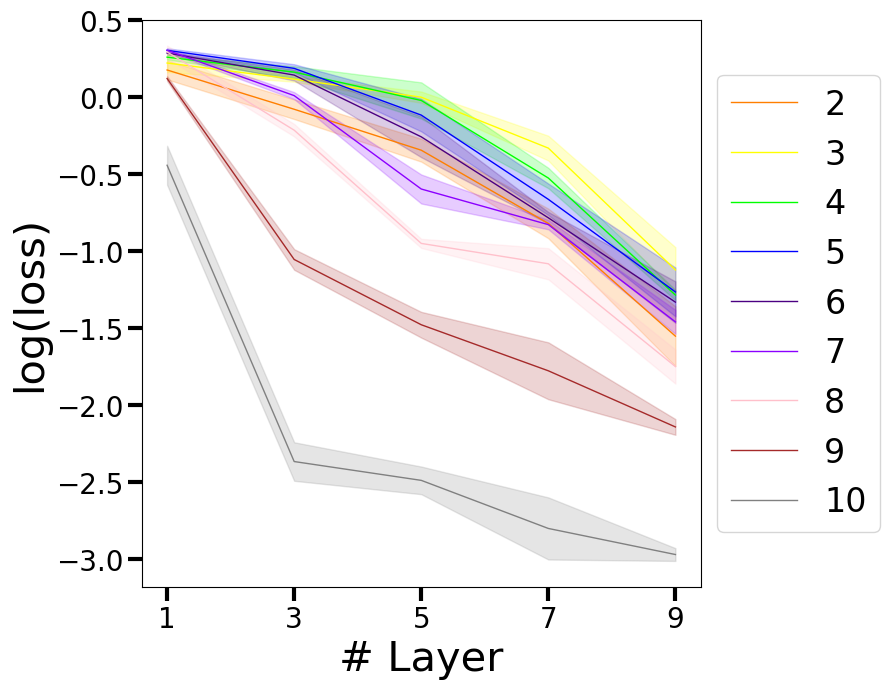

In [10]:
n_head = 1
losses_ev = torch.zeros(len(n_layers), n, len(seeds))

for i in range(len(n_layers)):
    n_layer = n_layers[i]
    for seed in seeds:
        model_hist = hist_dict[(n_layer,n_head,seed)]
        model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
        with torch.no_grad():
            model.allparam.data = model_hist[-1]
            for j in range(n):
                losses_ev[i, j, seed] = L_ev_loss(model(Z), Z, [j]).log()
        
loss_mean_ev = torch.mean(losses_ev, axis=2).cpu().detach().numpy()
loss_std_ev = torch.std(losses_ev, axis=2).cpu().detach().numpy()
    
fig, ax = plt.subplots(1, 1,figsize = (9, 7))

c = [
    "#FF0000",  # Red
    "#FF7F00",  # Orange
    "#FFFF00",  # Yellow
    "#00FF00",  # Green
    "#0000FF",  # Blue
    "#4B0082",  # Indigo
    "#8B00FF",  # Violet
    "#FFC0CB",  # Pink
    "#A52A2A",  # Brown
    "#808080"   # Gray
]

for j in [1,2,3,4,5,6,7,8,9]:
    plt.plot(n_layers, loss_mean_ev[:,j], color=c[j], lw = 1, label='{}'.format(j+1))
    ax.fill_between(n_layers, loss_mean_ev[:,j]-loss_std_ev[:,j], loss_mean_ev[:,j]+loss_std_ev[:,j], color = c[j], alpha = 0.2)


ax.set_xlabel('# Layer',fontsize=30)
ax.set_ylabel('log(loss)',fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20, width = 3, length = 10)
ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
ax.legend(fontsize=24, loc='center left', bbox_to_anchor=(1, 0.5))

plt.xticks([1,3,5,7,9])

plt.tight_layout()
#plt.savefig(fig_dir + '/ev_loss_per_ev_layer_csl{}.pdf'.format(settings['num_ev']), dpi=600)